In [ ]:
import pandas as pd
import torch
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
import re
import nltk
from nltk.corpus import stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import joblib
import random
import matplotlib.pyplot as plt

In [12]:
# Список тем 
topic_names = {
    0: 'Поддержка по горячей линии',  
    1: 'Выпуск UnionPay карт',       
    2: 'Навязанные услуги',        
    3: 'Выпуск дебетовых и кредитных карт',             
    4: 'Банковский счет',          
    5: 'Кэшбэк',             
    6: 'Вознаграждение за друга',             
    7: 'Сертификаты Озон',          
    8: 'Очная консультация с сотрудником банка',        
    9: 'Премиум пакет услуг',             
    10: 'Чат и техническая поддержка'          
}

In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in words_to_delete])
    return text

In [4]:
vectorizer = joblib.load('tfidf_vectorizer.pkl')
nmf = joblib.load('nmf_model.pkl')
words_to_delete = joblib.load('words_to_delete.pkl')
threshold = joblib.load('threshold.pkl')

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.6.1 when using version 1.7.2. This might lead to breaking code

In [5]:
def predict_multilabel(texts):
    if isinstance(texts, str):
        texts = [texts]
    preprocessed = [preprocess_text(text) for text in texts]
    X_new = vectorizer.transform(preprocessed)
    W_new = nmf.transform(X_new)
    W_normalized_new = normalize(W_new, norm='l1', axis=1)
    labels_new = (W_normalized_new > threshold).astype(int)
    topics_list = [list(np.where(row == 1)[0]) for row in labels_new]
    named_topics = [[topic_names[i] for i in topics] for topics in topics_list]
    return named_topics

In [6]:
# Загрузка модели тональности 
model_path = './fine_tuned_rubert_sentiment' 
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

In [7]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    label = torch.argmax(probs).item()
    labels_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return labels_map[label]

In [10]:
def topic_and_sentiment(text):
    results = {
        'Topic': predict_multilabel(text),
        'Mood': predict_sentiment(text)
    }
    return results

In [8]:
# Загрузка и предобработка
df = pd.read_csv('data_gazprom.csv', sep=';', on_bad_lines='skip')
df = df.sample(n=250, random_state=42)
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
texts = df['text'].tolist()
preprocessed_texts = [preprocess_text(text) for text in texts]

In [9]:
print(df.head())

           date                                               text  rating
1858 2024-12-08  Добрый вечер. Сегодня 08.12.2024 с 17:40-17:50...       1
3536 2024-10-09  Самый долгий банк из всех, кто так длительно о...       1
1128 2025-02-02  31.01 оплатила заправку топлива с карты Газпро...       1
4706 2024-08-11  Доброго времени суток! Сегодня, 10.08.2024, я ...       1
931  2025-02-21  В ответ на ОБРАЩЕНИЕ : Прошу вернуть мне 5тр. ...       5


In [11]:
print(topic_and_sentiment('''Техподдержка не работает в принципе. 
Операторов нет. Сейчас время ожидания на телефоне 30.30 мин. Уже 10 мин заявляют,
что время ожидания составляет 1 минуту. Информация о бонусных баллах на карте то появляется,
то исчезает. "Что-то не сработало. Попробуйте еще раз позже". И так с пятницы. Воспользоваться
баллами невозможно. Ужасный банк'''))

{'Topic': [['Поддержка по горячей линии']], 'Mood': 'negative'}


In [15]:
# Добавление столбца predicted_sentiment
df['predicted_sentiment'] = df['text'].apply(predict_sentiment)

# Добавление столбца topics
df['topics'] = df['text'].apply(lambda x: [i for i, name in topic_names.items() if name in predict_multilabel(x)[0]])

In [16]:
print(df.head())

           date                                               text  rating  \
1858 2024-12-08  Добрый вечер. Сегодня 08.12.2024 с 17:40-17:50...       1   
3536 2024-10-09  Самый долгий банк из всех, кто так длительно о...       1   
1128 2025-02-02  31.01 оплатила заправку топлива с карты Газпро...       1   
4706 2024-08-11  Доброго времени суток! Сегодня, 10.08.2024, я ...       1   
931  2025-02-21  В ответ на ОБРАЩЕНИЕ : Прошу вернуть мне 5тр. ...       5   

     predicted_sentiment     topics  
1858            negative        [4]  
3536            negative    [6, 10]  
1128            negative  [2, 4, 5]  
4706            negative    [4, 10]  
931             negative        [1]  


In [17]:
def sentiment_dynamics_by_topic(start_date='2024-01-01', end_date='2025-05-31'):
    
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
    if df['date'].isna().any():
        print(f"Обнаружено {df['date'].isna().sum()} NaT в столбце date. Удаляем эти строки.")
        df.dropna(subset=['date'], inplace=True)

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    mask = (df['date'] >= start_date) & (df['date'] <= end_date)
    filtered_df = df[mask].copy()
    
    exploded = filtered_df.explode('topics')
    exploded['topic_name'] = exploded['topics'].map(topic_names)
    exploded = exploded.dropna(subset=['topic_name'])  
    
    if exploded.empty:
        print("Нет данных для выбранного периода или тем. Проверь фильтр дат или topics.")
        return None
    
    exploded['month'] = exploded['date'].dt.to_period('M')
    grouped = exploded.groupby(['month', 'topic_name', 'predicted_sentiment']).size().unstack(fill_value=0)

    for topic in topic_names.values():
        if topic in grouped.index.get_level_values('topic_name'):
            topic_data = grouped.xs(topic, level='topic_name').div(
                grouped.xs(topic, level='topic_name').sum(axis=1), axis=0
            ) * 100
            topic_data = topic_data.round(2)
            print(f"\nДинамика тональностей для '{topic}' (доли % по месяцам):")
            print(topic_data)
            
            # График
            topic_data.plot(kind='line', figsize=(10, 5))
            plt.title(f"Доли тональностей для '{topic}'")
            plt.ylabel('Доля (%)')
            plt.xlabel('Месяц')
            plt.legend(title='Тональность')
            plt.grid(True)
            plt.show()
        else:
            print(f"\nТема '{topic}' не найдена в данных за выбранный период.")
    
    return grouped


Динамика тональностей для 'Поддержка по горячей линии' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-08                100.00      0.00
2024-09                100.00      0.00
2024-10                100.00      0.00
2024-11                 88.89     11.11
2024-12                100.00      0.00
2025-01                100.00      0.00
2025-02                100.00      0.00
2025-03                100.00      0.00
2025-05                100.00      0.00


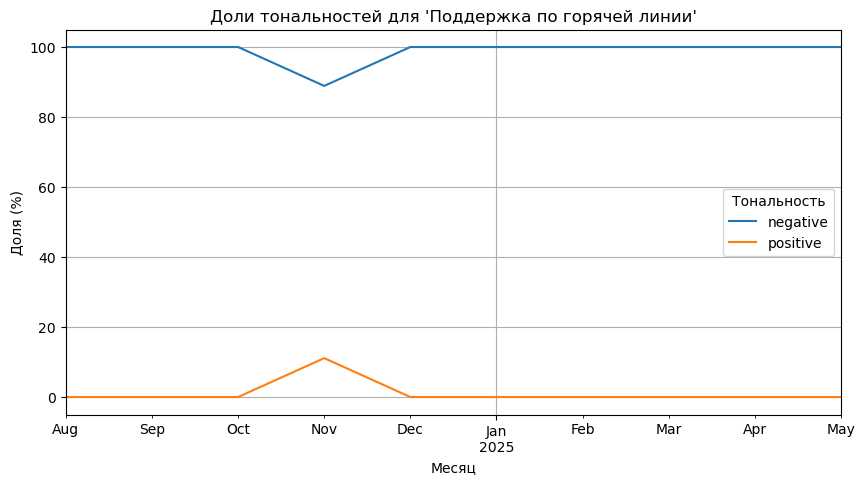


Динамика тональностей для 'Выпуск UnionPay карт' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                 100.0       0.0
2024-08                 100.0       0.0
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                 100.0       0.0
2025-05                 100.0       0.0


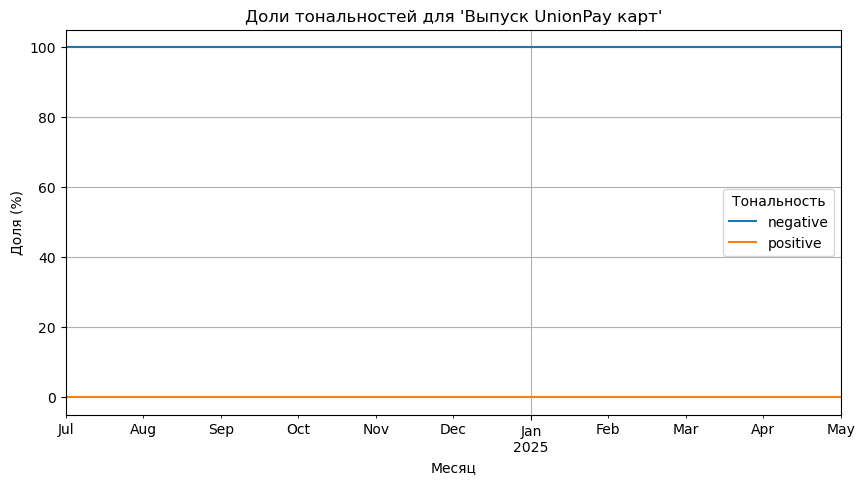


Динамика тональностей для 'Навязанные услуги' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-08                 100.0       0.0
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                 100.0       0.0


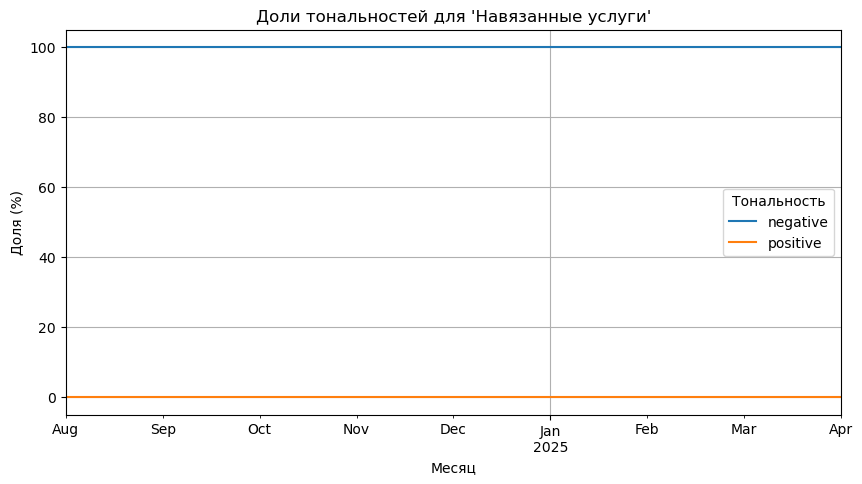


Динамика тональностей для 'Выпуск дебетовых и кредитных карт' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                 100.0       0.0
2024-08                 100.0       0.0
2024-09                  87.5      12.5
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                  75.0      25.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                 100.0       0.0
2025-05                 100.0       0.0


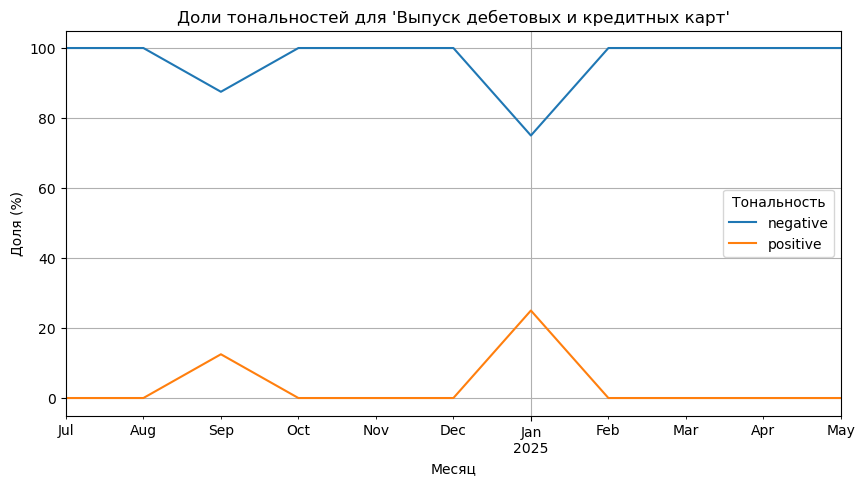


Динамика тональностей для 'Банковский счет' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                 100.0       0.0
2024-08                 100.0       0.0
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                 100.0       0.0
2025-05                  80.0      20.0


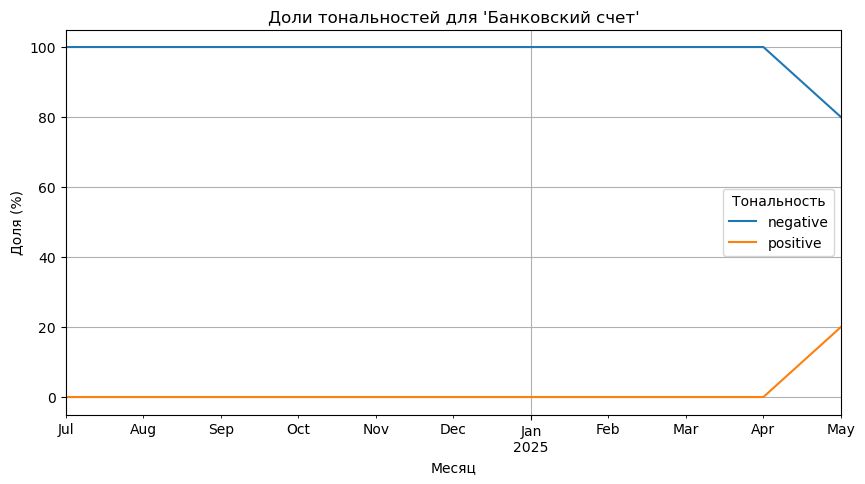


Динамика тональностей для 'Кэшбэк' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                 100.0       0.0
2024-08                 100.0       0.0
2024-09                  80.0      20.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                 100.0       0.0
2025-05                 100.0       0.0


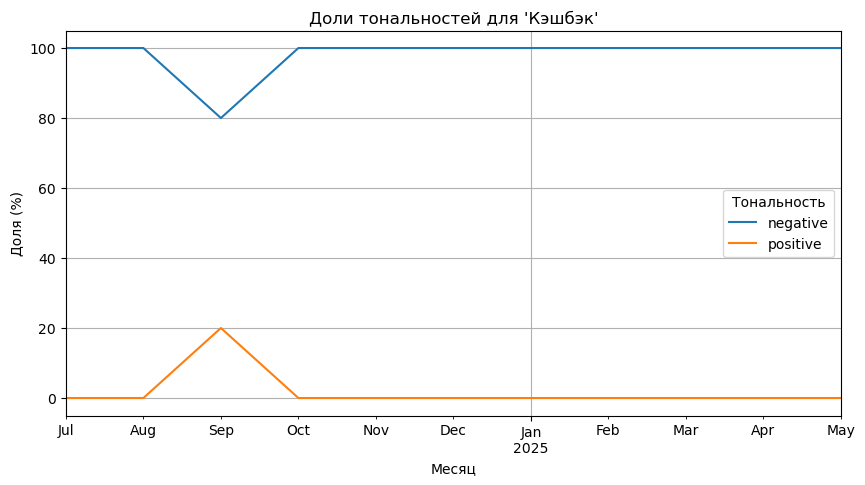


Динамика тональностей для 'Вознаграждение за друга' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                100.00      0.00
2024-09                100.00      0.00
2024-10                100.00      0.00
2024-11                100.00      0.00
2025-01                100.00      0.00
2025-02                100.00      0.00
2025-03                100.00      0.00
2025-04                 66.67     33.33
2025-05                100.00      0.00


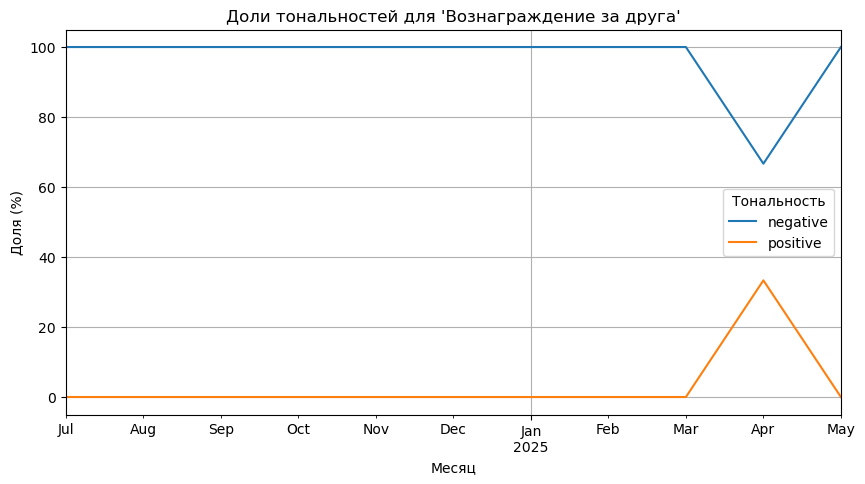


Динамика тональностей для 'Сертификаты Озон' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-08                 100.0       0.0
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2025-01                  50.0      50.0


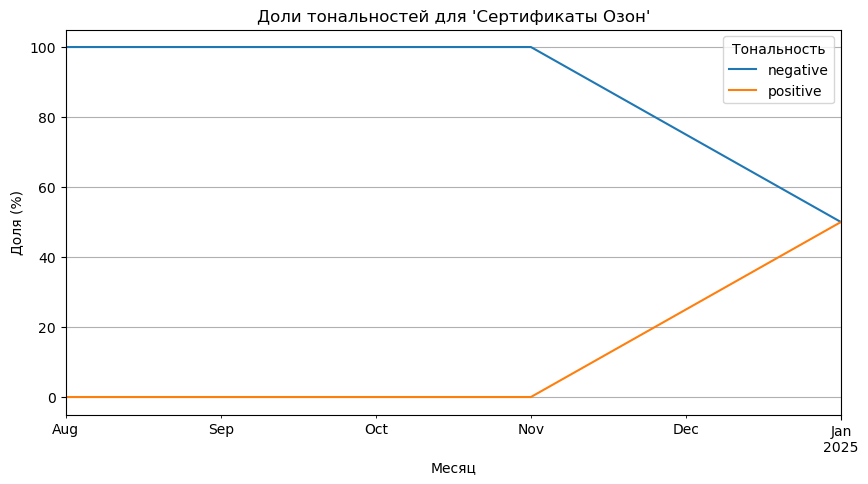


Динамика тональностей для 'Очная консультация с сотрудником банка' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                 50.00     50.00
2024-08                100.00      0.00
2024-09                 60.00     40.00
2024-10                 80.00     20.00
2024-11                 75.00     25.00
2024-12                 50.00     50.00
2025-01                  0.00    100.00
2025-02                 50.00     50.00
2025-03                 33.33     66.67
2025-04                 25.00     75.00
2025-05                 33.33     66.67


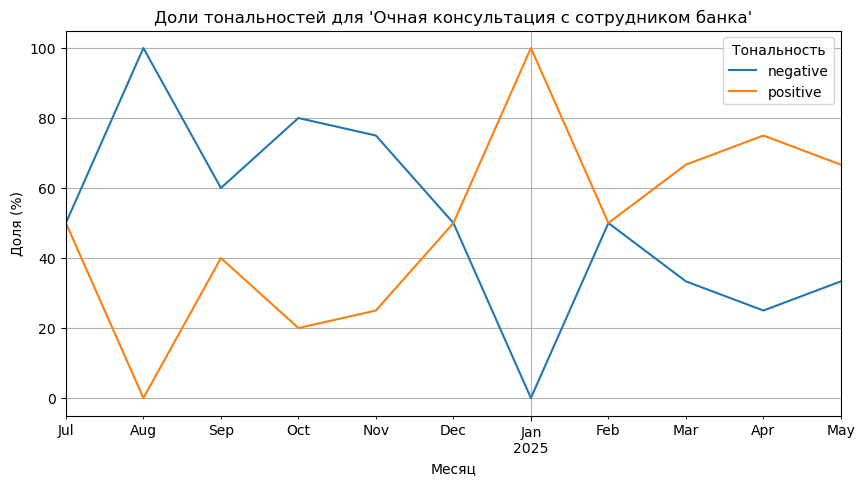


Динамика тональностей для 'Премиум пакет услуг' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-03                 100.0       0.0
2025-05                 100.0       0.0


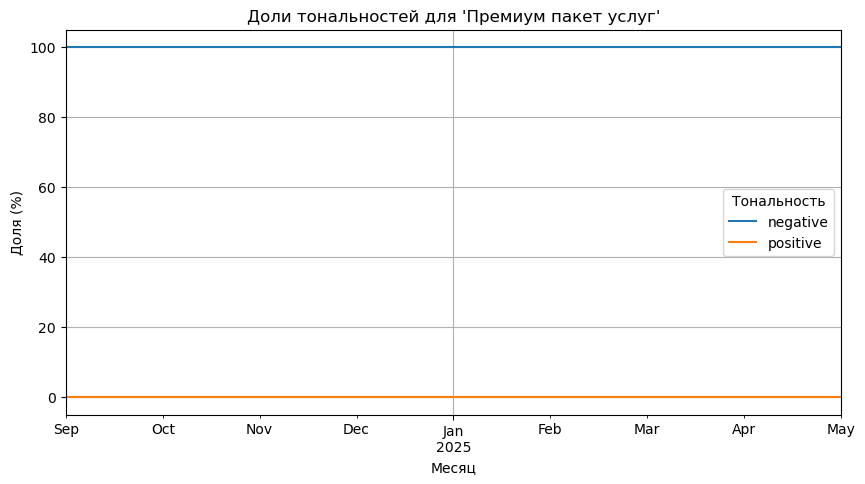


Динамика тональностей для 'Чат и техническая поддержка' (доли % по месяцам):
predicted_sentiment  negative  positive
month                                  
2024-07                  75.0      25.0
2024-08                 100.0       0.0
2024-09                 100.0       0.0
2024-10                 100.0       0.0
2024-11                 100.0       0.0
2024-12                 100.0       0.0
2025-01                 100.0       0.0
2025-02                 100.0       0.0
2025-03                 100.0       0.0
2025-04                  50.0      50.0
2025-05                 100.0       0.0


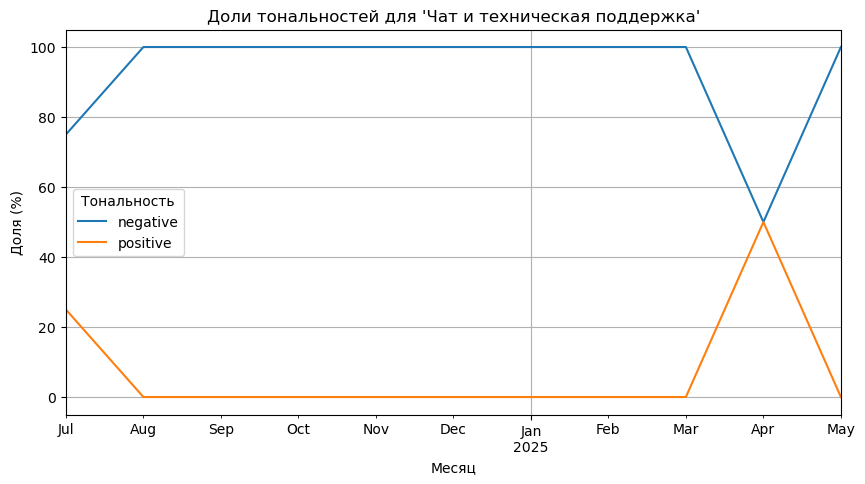

predicted_sentiment                             negative  positive
month   topic_name                                                
2024-07 Банковский счет                                2         0
        Вознаграждение за друга                        2         0
        Выпуск UnionPay карт                           6         0
        Выпуск дебетовых и кредитных карт              7         0
        Кэшбэк                                         3         0
...                                                  ...       ...
2025-05 Кэшбэк                                         1         0
        Очная консультация с сотрудником банка         1         2
        Поддержка по горячей линии                     2         0
        Премиум пакет услуг                            1         0
        Чат и техническая поддержка                    1         0

[104 rows x 2 columns]

In [18]:
sentiment_dynamics_by_topic('2024-06-01', '2025-05-31')